# Setup


In [1]:
# Standard library imports
import warnings
from itertools import combinations

# Third-party imports: core data -> modeling -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit

from scipy.special import comb

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

The imports are grouped on purpose, and the grouping is the same one used throughout this series: first the **standard library**, then third-party packages ordered *core data → modeling → visualization*.

From the standard library we take `warnings` (to silence the `FutureWarning` chatter that pandas and scikit-learn emit about upcoming API changes - noise for our purposes) and **`itertools.combinations`**, which enumerates all ways of choosing *k* items out of *n*. That little function is the engine of the final method in the notebook, Combinatorial Purged CV.

**`numpy`** (aliased `np`, the universal convention) provides fast numerical arrays; **`pandas`** (`pd`) provides the labeled `DataFrame` we will hold our sales panel in; **`matplotlib.pyplot`** (`plt`) draws every figure. Two small matplotlib helpers ride along: `LinearSegmentedColormap` builds the blue-to-orange color scale used by our fold-anatomy heatmaps, and `Patch` supplies the colored swatches for their legends.

From scikit-learn we import one model and three splitting tools. **`HistGradientBoostingRegressor`** is our workhorse forecaster: a histogram-based gradient-boosted tree ensemble that is fast on tens of thousands of rows, captures nonlinear interactions without feature scaling, and - importantly for this notebook - is greedy enough to *exploit any leak we leave open*. A model too weak to cheat would hide the very problem we want to expose. **`train_test_split`** and **`KFold`** are the two standard validators we will demonstrate to be broken for time series; **`TimeSeriesSplit`** is the first correct one. The more advanced splitters do not ship with scikit-learn, so we will build them ourselves.

Finally, `scipy.special.comb` computes binomial coefficients - we use it to count CPCV's folds and backtest paths before running them.

In [2]:
# general settings
class CFG:
    data_folder   = './data/'
    graph_folder  = './graphs/'
    img_dim1      = 16
    img_dim2      = 6
    SEED          = 42
    metric        = 'rmse'
    # dataset & problem shape
    store         = 1       # which store's items we model (50 parallel daily series)
    horizon       = 7       # the label looks THIS many days into the future
    roll_window   = 28      # the rolling feature looks THIS many days into the past
    holdout_days  = 90      # sealed "future": the final 90 days, untouched until the very end
    n_folds       = 5

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This `CFG` ("config") class is the single place where every tunable constant in the notebook lives. It is not a real object - we never instantiate it - just a named container, so that no unexplained "magic numbers" appear in the body of the notebook and any experiment ("what if the holdout were 60 days?") means editing one line here.

Three of these constants define the *shape of the forecasting problem*, and they matter enormously for what comes later:

- **`horizon = 7`**: our prediction target will be the *average daily sales over the next 7 days* - a realistic demand-planning quantity. Crucially, this means the label attached to day *t* is computed from sales on days *t+1 … t+7*. The label has a **look-ahead footprint**: it contains information from 7 days of the future.
- **`roll_window = 28`**: one of our features will be a 28-day rolling mean of past sales. That feature has a **look-back footprint**: it contains information from 28 days of the past.
- **`holdout_days = 90`**: the final 90 days of data are locked away as the sealed test set - our stand-in for "the future". No validation method is allowed to touch it; every method's job is to *estimate* the error we will eventually measure there.

Those two footprints - 7 days forward for the label, 28 days back for the feature - are exactly the quantities that the purging and embargo machinery in the second half of the notebook exists to handle. We flag them here so they are already familiar when they return.

The remaining lines set the plotting theme (`seaborn-v0_8`, a clean grid style), the default figure size, and the master random seed. `np.random.seed(CFG.SEED)` pins NumPy's global random generator so that every "random" operation - the shuffled splits, the model's internal randomness - produces identical results on every run. The value 42 is arbitrary; *fixing* it is what matters for reproducibility.

# Utils

Before any modeling we write the small reusable helpers the rest of the notebook leans on. The design principle: anything we would otherwise do more than twice becomes a function here, so that later cells read as short declarative calls - and, most importantly, so that **the only thing that differs between validation methods is the splitter itself**. Same data, same model, same metric, same code path: any difference in the numbers is then attributable to the validation scheme and nothing else.

In [3]:
def rmse(y_true, y_pred):
    """Root-mean-squared error, rounded. Lower is better."""
    return float(np.round(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)), 4))

Our single evaluation metric is the **root-mean-squared error (RMSE)**: take the differences between predictions and truth, square them (so over- and under-shooting both count, and big misses count disproportionately), average, and take the square root to return to the original units - here, *units of daily sales*. An RMSE of 5 means the model's 7-day-ahead demand estimate is typically off by about 5 units per item-day.

The `np.asarray` calls let the function accept lists, pandas Series, or NumPy arrays interchangeably; the rounding to 4 decimals and the cast to plain `float` keep the printed tables tidy. Lower is better throughout.

In [4]:
def get_model():
    """Return a fresh, identically-configured model so every fold/method is comparable."""
    return HistGradientBoostingRegressor(
        max_depth=4, max_iter=200, learning_rate=0.08, random_state=CFG.SEED
    )

Every time we need a model we call `get_model()` rather than reusing one instance. This matters for a subtle reason: a fitted scikit-learn estimator carries its learned state with it, and calling `.fit()` again re-trains it *from that configuration* - fine in itself, but it invites accidental state sharing between folds. A factory function guarantees each fold trains a genuinely fresh model with byte-for-byte identical hyperparameters, so cross-method comparisons are clean.

The hyperparameters are deliberately modest and deliberately *not tuned*: trees of depth 4, 200 boosting iterations, a learning rate of 0.08. We are not chasing the best possible forecaster - we are comparing validation schemes, and any reasonable model would do. `random_state=CFG.SEED` pins the model's internal randomness (feature binning ties, etc.) so repeated fits on the same data give the same result.

In [5]:
def cv_estimate(splitter, X, y, groups=None, return_scores=False):
    """Run a splitter over (X, y), fit a fresh model per fold, return mean validation RMSE.

    If `groups` is given it is forwarded to the splitter (needed by the group-aware
    splitters). Set `return_scores=True` to also get the per-fold list back.
    """
    X = np.asarray(X); y = np.asarray(y)
    fold_scores = []
    for train_idx, val_idx in splitter.split(X, groups=groups):
        model = get_model().fit(X[train_idx], y[train_idx])
        fold_scores.append(rmse(y[val_idx], model.predict(X[val_idx])))
    mean_score = float(np.round(np.mean(fold_scores), 4))
    return (mean_score, fold_scores) if return_scores else mean_score

This is the engine that every validation method below runs through. It takes any object with a scikit-learn-style `.split()` method - the built-in `KFold` and `TimeSeriesSplit`, or the custom splitters we write later - and does the same four things per fold: get the train/validation row indices, fit a fresh model on the training rows, predict the validation rows, and score with RMSE. The mean across folds is the method's *claim* about the model's out-of-sample error.

Two small design points. The `groups` argument is forwarded to the splitter because the group-aware splitters need to know which day each row belongs to; the plain splitters simply ignore it. And `return_scores=True` hands back the individual fold scores - a detail that becomes the whole point when we reach CPCV, where the per-fold *distribution* is the deliverable, not the mean.

In [6]:
# blue = pure train, orange = pure validation; the violet midpoint makes
# partially-split days stand out instead of hiding as a faint tint
CV_CMAP = LinearSegmentedColormap.from_list(
    "cv", [(0.0, "#4C72B0"), (0.3, "#8A5FA8"), (1.0, "#DD8452")])
CV_CMAP.set_bad("#E8E8E8")   # days not used at all in a fold -> light grey

def plot_cv_indices(splitter, X, groups, title):
    """Fold anatomy as a heatmap: one row per fold, one column per day, colored by the
    share of that day's rows landing in validation (blue = all train, orange = all
    validation, blends = the day is split, grey = the day is unused in that fold)."""
    X = np.asarray(X); days = np.asarray(groups)
    uniq = np.unique(days)                                  # the days, in time order
    col_of_row = np.searchsorted(uniq, days)                # column position of every row
    folds = list(splitter.split(X, groups=groups))
    grid = np.full((len(folds), len(uniq)), np.nan)
    for f, (train_idx, val_idx) in enumerate(folds):
        n_tr  = np.bincount(col_of_row[train_idx], minlength=len(uniq))
        n_val = np.bincount(col_of_row[val_idx],   minlength=len(uniq))
        used = (n_tr + n_val) > 0
        grid[f, used] = n_val[used] / (n_tr[used] + n_val[used])

    fig, ax = plt.subplots(figsize=(CFG.img_dim1, 0.45 * len(folds) + 1.8))
    ax.imshow(grid, aspect="auto", cmap=CV_CMAP, vmin=0, vmax=1, interpolation="nearest")
    ax.set(xlabel="day position (chronological)", ylabel="CV fold",
           title=title, yticks=range(len(folds)))
    ax.legend(handles=[Patch(color="#4C72B0", label="train"),
                       Patch(color="#DD8452", label="validation"),
                       Patch(color="#8A5FA8", label="day split between both"),
                       Patch(color="#E8E8E8", label="unused / purged")],
              loc="upper left", bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout(); plt.show()

Numbers alone make it hard to *see* why a split leaks, so this helper draws the anatomy of any scheme - and because our development set has ~85,000 rows but only ~1,700 distinct days, it draws at the **day** level, which is the level that matters for every leak in this notebook.

The mechanics: `np.unique` lists the distinct days in chronological order, and `np.searchsorted` maps every row to its day's column position. For each fold we then count, per day, how many rows went to training (`np.bincount` over the training rows' columns) and how many to validation, and store the **validation share** of each day in a folds × days grid. `ax.imshow` renders that grid as an image, one row of pixels per fold, with a custom color scale: a day that is entirely training paints **blue**, entirely validation paints **orange**, and - the tell-tale of subtle leakage - a day *split between the two* paints **violet** (the colormap places its violet waypoint at a 30% validation share, so even lightly contaminated days stand out instead of hiding as a faint tint). Days that appear in neither set stay `NaN`, which the colormap's `set_bad` renders **light grey**: that is how deliberately discarded data (the purge gaps and embargoes of the later methods) will show up.

Since the columns run chronologically, **left is the past and right is the future**, and one glance tells you whether a method respects the arrow of time: honest schemes show solid blue strictly to the left of solid orange; leaky ones show orange mixed through the timeline. The `Patch` legend sits outside the axes so it never covers data.

In [7]:
def summarise(name, val_rmse, true_rmse):
    """One tidy row: what the CV claimed, the true error, and the optimism gap."""
    return {
        "method": name,
        "cv_val_rmse": val_rmse,
        "true_test_rmse": true_rmse,
        "optimism": float(np.round(val_rmse - true_rmse, 4)),  # negative = over-optimistic
    }

The final helper records each method's verdict in a uniform little dictionary so that, at the end, a list of these becomes the summary `DataFrame` with one call. The key column is **`optimism`**, defined as *validation claim minus true test error*. Read its sign carefully, because the whole notebook turns on it:

- **Negative optimism** means the method claimed a *lower* error than reality delivered - it was over-optimistic. This is the dangerous direction: you ship a model believing it is better than it is, and the gap is a direct, quantitative measure of the leaked future information the method let through.
- **Positive optimism** means the method was conservative - it claimed things were worse than they turned out. Mildly wasteful, but safe.
- **Near zero** is the goal: an honest estimate of future performance.

# Groundwork: a real retail panel

To compare validation methods we need one luxury that practitioners never have at decision time: **access to the future**. We manufacture it the only honest way - by cutting off the final 90 days of a real dataset and sealing them away. Everything before the cut is "the present", where validation methods operate; everything after is "the future", touched exactly once per method to reveal how honest its claim was.

The dataset is the classic **store-item demand** set from Kaggle's Store Item Demand Forecasting Challenge: five years (2013–2017) of genuine daily unit sales for 50 items in each of 10 retail stores. We keep one store, which gives us 50 parallel daily series observed on every date - roughly 91,000 rows.

The structure matters as much as the content. This is **panel data**: at every timestamp we observe many entities at once, exactly like the Ubiquant market-prediction data (one `time_id`, many `investment_id`s) that motivates much of the validation literature. Items in the same store share a common environment - the same promotions calendar, the same weather, the same seasonal shopping patterns - so their sales on any given day are *contemporaneously correlated*. Hold that thought: it is precisely the property that will eventually break row-level splitting and force us to group-aware methods.

In [8]:
raw = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])
df = raw[raw['store'] == CFG.store].copy()

print("full dataset:", raw.shape, " one store:", df.shape)
print("date range  :", df['date'].min().date(), "to", df['date'].max().date(),
      " items:", df['item'].nunique())
df.head(3)

full dataset: (913000, 4)  one store: (91300, 4)
date range  : 2013-01-01 to 2017-12-31  items: 50


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14


`pd.read_csv` loads the file into a `DataFrame`; the `parse_dates=['date']` argument tells pandas to convert the `date` column from plain text into proper `datetime64` timestamps at load time, which is what later unlocks calendar arithmetic (`.dt.dayofweek`, date subtraction) - without it, dates would be inert strings.

The second line filters to a single store. The boolean mask `raw['store'] == CFG.store` selects matching rows, and the trailing **`.copy()`** is important: it makes `df` an independent DataFrame rather than a view into `raw`, so the columns we add next never trigger pandas' warnings about modifying a slice, and `raw` stays pristine.

The printout confirms what we have: 91,300 rows covering exactly five calendar years, 50 items, four columns - `date`, `store`, `item`, `sales`. And as always after any non-trivial data step, `df.head(3)` gives the three-row sanity check: one row per (date, item) pair, integer unit sales. A habit worth keeping - most data bugs are visible in three rows if you actually look.

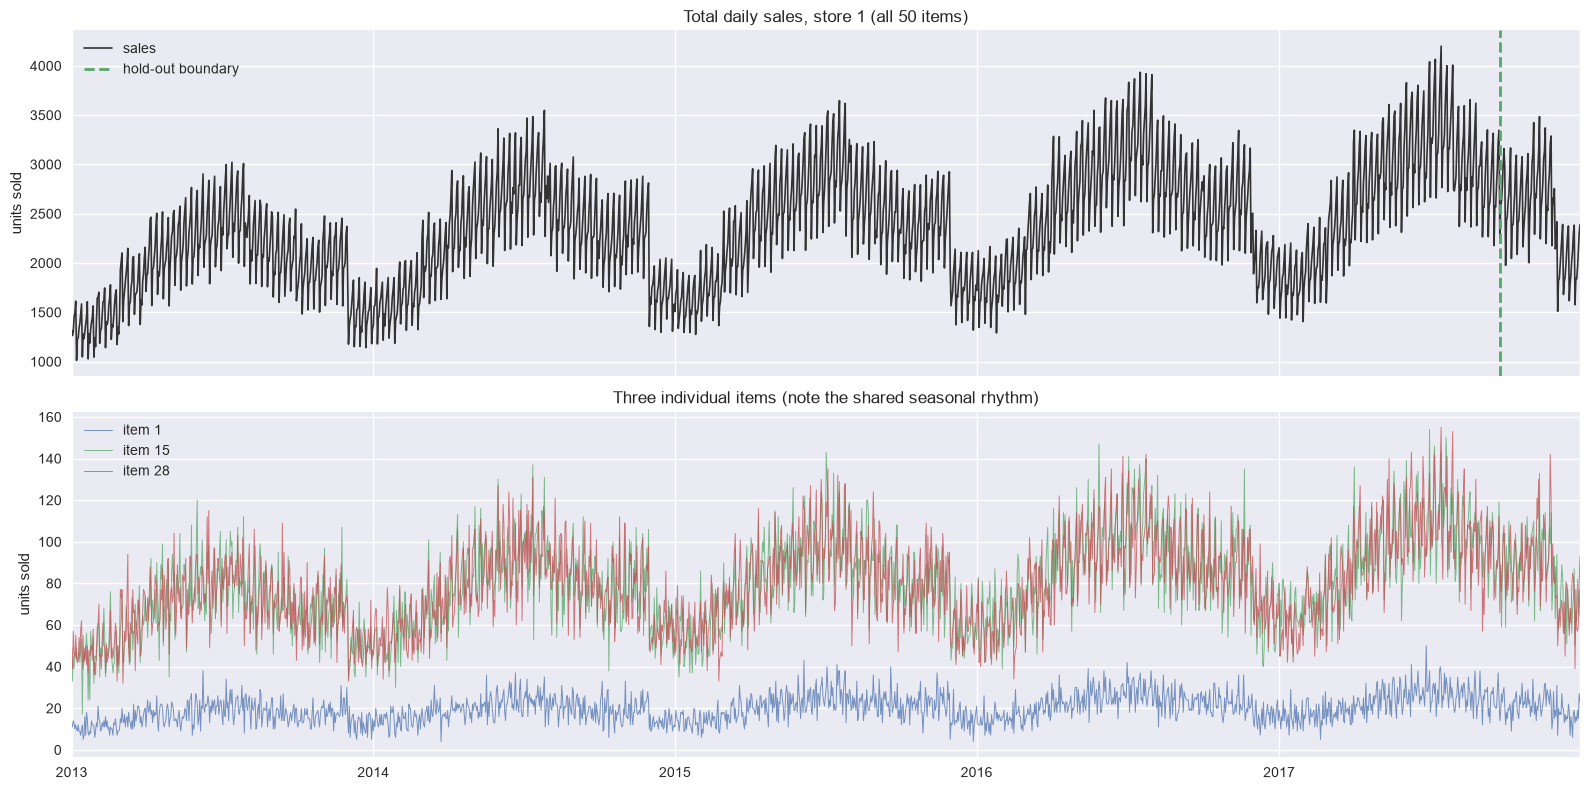

In [9]:
# Plot the raw data before any modelling.
holdout_start = df['date'].max() - pd.Timedelta(days=CFG.holdout_days + CFG.horizon)

fig, axes = plt.subplots(2, 1, figsize=(CFG.img_dim1, 8), sharex=True)

# Top: total daily sales across all 50 items -> trend + yearly cycle.
daily_total = df.groupby('date')['sales'].sum()
daily_total.plot(ax=axes[0], linewidth=1.2, color="#333333")
axes[0].axvline(holdout_start, color="#55A868", linestyle="--", linewidth=2,
                label="hold-out boundary")
axes[0].set(title=f"Total daily sales, store {CFG.store} (all 50 items)", ylabel="units sold")
axes[0].legend()

# Bottom: three individual items -> they share the same rhythm.
for item in [1, 15, 28]:
    sub = df[df['item'] == item]
    axes[1].plot(sub['date'], sub['sales'], linewidth=0.7, alpha=0.75, label=f"item {item}")
axes[1].set(title="Three individual items (note the shared seasonal rhythm)",
            xlabel="", ylabel="units sold")
axes[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

A plot of the raw data always comes before any modeling. The top panel aggregates all 50 items into total daily store sales, and three features jump out immediately, each with a consequence for validation:

- **An upward trend**: sales in 2017 run visibly higher than in 2013. The mean of the series changes over time - the textbook definition of **non-stationarity**. A model trained on early years faces a future that sits at levels it has never seen, so "how hard is the future?" genuinely depends on *which* future - something a validation scheme that scrambles time can never respect.
- **A strong yearly cycle**: peaks each summer, troughs each winter. Performance therefore depends on *where in the year* a validation block happens to fall - a first hint of why a single train/test path can mislead.
- **A weekly sawtooth**: the fine zigzag texture is the weekend/weekday rhythm, which we will confirm with the autocorrelation plot next.

The bottom panel shows three individual items. They differ in level but move to the *same* rhythm - the shared store environment produces strong **contemporaneous correlation across items on the same day**. This is the panel structure that will eventually demand group-aware splitting.

The dashed green line marks the hold-out boundary: everything to its right is the sealed future. (It sits `holdout_days + horizon` from the end because the final `horizon` days cannot receive a label at all - their "next 7 days" run off the end of the data.)

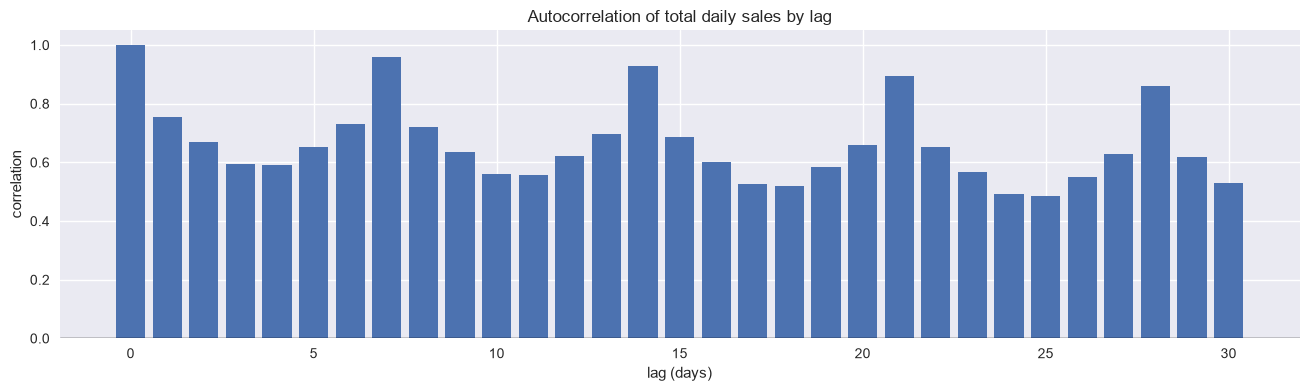

In [10]:
# First-look diagnostic: how serially correlated is the series?
acf = [daily_total.autocorr(lag=k) for k in range(0, 31)]
plt.figure(figsize=(CFG.img_dim1, 4))
plt.bar(range(0, 31), acf, color="#4C72B0")
plt.axhline(0, color="black", linewidth=1)
plt.title("Autocorrelation of total daily sales by lag")
plt.xlabel("lag (days)"); plt.ylabel("correlation"); plt.show()

One more first-look diagnostic before modeling: the **autocorrelation function (ACF)** of daily sales at lags 0 through 30. `Series.autocorr(lag=k)` computes the correlation between the series and a copy of itself shifted back by *k* days; the loop collects these into a bar per lag. Lag 0 is a series correlated with itself, so it is 1.0 by definition and serves as the reference bar.

Two things to read off the picture. First, the **overall level**: the correlations stay high across all 30 lags - knowing today's sales tells you a great deal about sales next week and even next month, because trend and season carry over. Adjacent observations are *highly redundant*. This is exactly the property that breaks the i.i.d. (independent and identically distributed) assumption underlying random splits: putting today in the training set and tomorrow in the validation set hands the model most of the answer.

Second, the **shape**: pronounced ripples at lags 7, 14, 21, 28 - the weekly cycle, confirmed. A Saturday is more like last Saturday than like yesterday.

Together with the trend from the previous plot, this is the profile of data on which shuffled validation fails hardest: strongly serially correlated *and* non-stationary. Keep these two facts in mind - every leak we demonstrate below is one of them being exploited.

In [11]:
# Feature engineering: everything a row may legally know, plus a forward-looking label.
df = df.sort_values(['item', 'date']).reset_index(drop=True)
by_item = df.groupby('item')['sales']

# look-back features (past only)
df['lag_7']        = by_item.shift(7)                # sales one week ago
df['lag_14']       = by_item.shift(14)               # sales two weeks ago
df['roll_mean_28'] = by_item.transform(
    lambda s: s.shift(1).rolling(CFG.roll_window).mean())   # average of the previous 28 days

# calendar features
df['dayofweek'] = df['date'].dt.dayofweek
df['month']     = df['date'].dt.month

# the LABEL: average daily sales over the NEXT `horizon` days
df['target'] = by_item.transform(
    lambda s: s.shift(-1).rolling(CFG.horizon).mean().shift(-(CFG.horizon - 1)))

# sanity check on one series: target at row t == mean of sales at rows t+1 .. t+7
one_item = df[df['item'] == 1].reset_index(drop=True)
assert np.isclose(one_item['target'].iloc[10], one_item['sales'].iloc[11:18].mean())

# rows whose features or label cannot be computed are dropped
df = df.dropna(subset=['lag_7', 'lag_14', 'roll_mean_28', 'target']).reset_index(drop=True)

# a day counter: the "group" label every advanced splitter will need
df = df.sort_values(['date', 'item']).reset_index(drop=True)
df['time_id'] = (df['date'] - df['date'].min()).dt.days
df['t_frac']  = df['time_id'] / df['time_id'].max()

print("after feature engineering:", df.shape, " distinct days:", df['time_id'].nunique())
df.head(3)

after feature engineering: (89550, 12)  distinct days: 1791


,date,store,item,sales,lag_7,lag_14,roll_mean_28,dayofweek,month,target,time_id,t_frac
0,2013-01-29,1,1,6,7.0,5.0,10.714286,1,1,13.142857,0,0.0
1,2013-01-29,1,2,35,29.0,27.0,29.285714,1,1,30.714286,0,0.0
2,2013-01-29,1,3,15,20.0,12.0,17.642857,1,1,23.285714,0,0.0


This cell turns raw sales into a supervised learning problem, and it is worth reading slowly because the *shape* of what we build here - what looks backward, what looks forward - determines everything the advanced validation methods must later defend against.

**The grouping discipline.** We first sort by `(item, date)` and take `df.groupby('item')['sales']`. Every lag and rolling computation is then done *within* each item's own history - `by_item.shift(7)` moves item 1's sales down 7 rows within item 1 only. Without the groupby, the shift would bleed the end of one item's series into the start of the next. (The `.transform(...)` calls apply a function per group and return a result aligned to the original rows.)

**Look-back features.** `lag_7` and `lag_14` are sales one and two weeks ago - the natural predictors given the weekly cycle. `roll_mean_28` is the average of the *previous* 28 days; note the `s.shift(1)` **before** `.rolling()`. This is important! It excludes today from its own rolling window; without it, the feature would contain the very day it describes. Each such feature has a 28-day look-back footprint: it summarizes a month of history into one number.

**The label.** The target for day *t* is the average of sales on days *t+1 … t+7*: `shift(-1)` aligns tomorrow onto today, `.rolling(horizon).mean()` averages a 7-day window, and the final `shift(-(horizon-1))` re-anchors the window so it *starts* rather than ends at tomorrow. Chained negative shifts are easy to get wrong, so the next line **asserts** the definition on one concrete row - the target at row 10 must equal the mean of sales at rows 11 through 17. Cheap insurance; if the assert passes silently, the label is what we claim.

**The consequence** is worth stating plainly: *the label at day t contains information from 7 future days.* Two rows just one day apart share 6 of their 7 label days - their targets are almost the same number. Any validation scheme that separates such neighbors into train and validation is grading the model on questions it has effectively seen answered.

`dropna` then removes the rows where features (first 28 days of each series) or labels (last 7 days) cannot exist - the model cannot digest NaNs. Finally we sort back to chronological order and build `time_id`, the number of days since the first usable date: this integer is the **group label** - "which day does this row belong to?" - that every group-aware splitter below will consume. `t_frac`, its rescaling to [0, 1], doubles as a simple trend feature for the model.

In [12]:
# Lock away the future: chronological hold-out, never touched until scoring time.
feat_cols = ['t_frac', 'dayofweek', 'month', 'sales', 'lag_7', 'lag_14', 'roll_mean_28']

cutoff_day = df['time_id'].max() - CFG.holdout_days

train_df = df[df['time_id'] <  cutoff_day].reset_index(drop=True)
test_df  = df[df['time_id'] >= cutoff_day].reset_index(drop=True)

X_train, y_train = train_df[feat_cols].values, train_df['target'].values
X_test,  y_test  = test_df[feat_cols].values,  test_df['target'].values
groups_train     = train_df['time_id'].values   # the group label = the day

print("development set:", X_train.shape, "  sealed hold-out:", X_test.shape)

development set: (85000, 7)   sealed hold-out: (4550, 7)


Now we draw the one split that is sacred: the **chronological hold-out**. Everything before `cutoff_day` becomes the *development set* - the world our validation methods live in. Everything from `cutoff_day` on (the final 90 days, about 4,500 rows) is the sealed test set, our stand-in for the genuine future.

Note what this split is *not*: it is not random. We simply cut the timeline at one date, because that is the only kind of split reality itself will ever perform on a forecasting model. The feature matrix uses `.values` to hand plain NumPy arrays to scikit-learn - `t_frac`, the two calendar columns, today's `sales`, the two lags, and the rolling mean. Raw identifiers (`item`, `store`, `date`) stay out: they are bookkeeping, not features.

We also keep `groups_train`, the `time_id` of every development row - the advanced splitters will need to know which rows belong to the same day. And to be explicit about the rules of the game: **no validation method below is allowed to touch `X_test`**. Each will produce its estimate using development data only, and then - once per method - we compare that claim against the sealed truth.

In [13]:
# The GROUND TRUTH: train once on all *usable* history, score once on the sealed future.
# Subtlety: labels of the last `horizon` development days are computed from hold-out-period
# sales -- at deployment time they would not exist yet, so an honest final fit drops them.
label_ready     = groups_train < (cutoff_day - CFG.horizon)
reference_model = get_model().fit(X_train[label_ready], y_train[label_ready])
true_test_rmse  = rmse(y_test, reference_model.predict(X_test))

print("True generalisation RMSE (the number every method below is trying to estimate):",
      true_test_rmse)

True generalisation RMSE (the number every method below is trying to estimate): 5.4454


This is the reference against which every validation method will be judged: train one model on the development history, score it once on the sealed 90 days. The resulting **true generalisation RMSE ≈ 5.45** is "the right answer" - a validation method is good exactly to the extent that its claim lands near this number *without ever seeing the hold-out*.

One line deserves a careful look: the `label_ready` mask. Remember that the label at day *t* is built from sales on days *t+1 … t+7*. For the last 7 days of the development period, those future sales fall **inside the hold-out window** - meaning that at the moment of deployment (the morning of the first hold-out day), those labels *could not have been computed yet*. Training on them would be a small but real act of time travel: the model would absorb information about the very period it is being tested on. The mask drops those boundary rows, making the reference fit something a real deployment could actually have performed.

On this dataset the effect is tiny - 7 days out of ~1,700 - but the principle is the point, and it is the same principle that returns at full scale as **purging** later in the notebook: *wherever a training label's look-ahead footprint overlaps evaluation data, those training rows must go.*

# The wrong way: shuffled validation

We start at the bottom of the ladder, with the two methods almost everyone reaches for first - the defaults of the tabular-ML world. Both share one fatal property: they treat rows as interchangeable, independent observations, shuffling them freely across the train/validation boundary. On i.i.d. data that is exactly right. On our data - serially correlated, non-stationary, with labels that physically overlap in time - it amounts to handing the model the answer key.

## Random split

A single random split holds out a random fraction of rows for validation and trains on the rest. With five years of interleaved history on both sides of the split, the model gets to "predict" each validation day while having trained on its immediate neighbors - often the very same week of the very same item.

In [14]:
RANDOM_VAL_FRACTION = 0.25

x0, x1, y0, y1 = train_test_split(
    X_train, y_train, test_size=RANDOM_VAL_FRACTION, random_state=CFG.SEED
)
random_model    = get_model().fit(x0, y0)
random_val_rmse = rmse(y1, random_model.predict(x1))

print("Random-split validation RMSE:", random_val_rmse)
print("True generalisation RMSE    :", true_test_rmse)
print("Optimism (val - true)       :", round(random_val_rmse - true_test_rmse, 4))

Random-split validation RMSE: 3.275
True generalisation RMSE    : 5.4454
Optimism (val - true)       : -2.1704


`train_test_split` with `test_size=0.25` pulls out a random quarter of the development rows as validation and trains on the remaining three quarters; the fixed `random_state` makes the draw reproducible. It shuffles by default - that default is the whole story of this section.

The verdict is spectacular: the random split claims an RMSE of about **3.3** when the truth is about **5.45** - it underestimates the error by roughly **40%**. If this were a real project, you would ship this model believing it nearly twice as accurate as it is.

Where does the fantasy come from? Two leaks, both flagged earlier, both now cashed in. First, **serial correlation**: for almost every validation row, rows from the same item just days away sit in the training set, and with lag and rolling-mean features those neighbors are nearly duplicate questions with known answers. Second, and worse, the **overlapping labels**: targets one day apart share 6 of their 7 constituent days. Training on Monday's row means having effectively seen ~86% of Tuesday's label. The model does not need to forecast anything; pattern-matching its own training data is enough.

The gap between 3.3 and 5.45 is not noise and not model instability - it is a *direct measurement of the value of leaked future information*. And note the deeper damage: a model selection process run against this number would systematically favor models that are best at *exploiting the leak*, not best at forecasting.

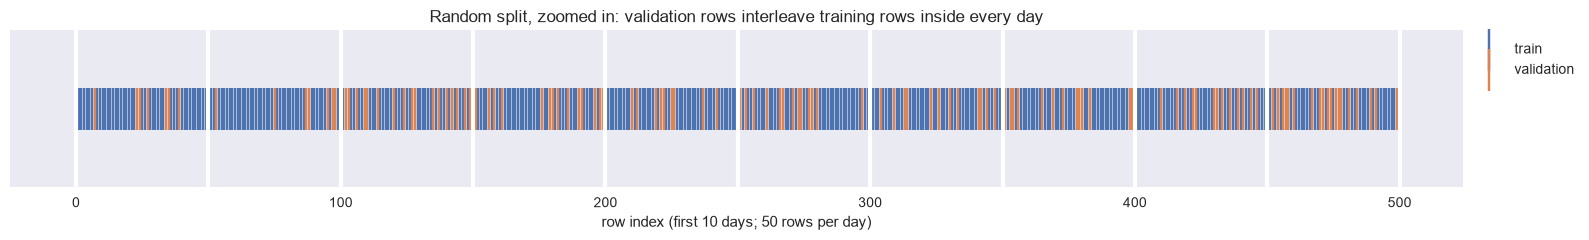

In [15]:
# Make the leakage visible: zoom into the first ten days of the timeline.
_, val_idx = train_test_split(np.arange(len(X_train)),
                              test_size=RANDOM_VAL_FRACTION, random_state=CFG.SEED)
val_mask = np.zeros(len(X_train), dtype=bool)
val_mask[val_idx] = True

n_items = df['item'].nunique()
ZOOM = 10 * n_items                     # ten days x 50 items = the first 500 rows
zoom_tr  = np.where(~val_mask[:ZOOM])[0]
zoom_val = np.where(val_mask[:ZOOM])[0]

plt.figure(figsize=(CFG.img_dim1, 2.5))
plt.scatter(zoom_tr,  np.zeros(len(zoom_tr)),  c="#4C72B0", marker="|", s=900, label="train")
plt.scatter(zoom_val, np.zeros(len(zoom_val)), c="#DD8452", marker="|", s=900, label="validation")
for d in range(0, ZOOM + 1, n_items):   # white separators between consecutive days
    plt.axvline(d, color="white", linewidth=3)
plt.yticks([]); plt.xlabel(f"row index (first 10 days; {n_items} rows per day)")
plt.title("Random split, zoomed in: validation rows interleave training rows inside every day")
plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0)); plt.tight_layout(); plt.show()

The picture confirms the diagnosis. Re-running the same seeded split on row *positions* (`np.arange(len(X_train))` with the identical `random_state`) recovers exactly which rows went to validation. All 85,000 rows will not fit legibly on one screen, so we zoom into the first ten days - 500 rows, with white lines separating consecutive days - and the pattern shown here repeats across the entire five-year timeline.

Orange validation ticks are interleaved with blue training ticks *inside every single day*. For nearly every validation row, the model trained on rows from the same day (other items sharing the same demand conditions), from the day before, and from the day after - the model trained on each validation row's past **and its future**. That is not a forecasting exercise; it is an interpolation exercise, and interpolation is easy.

## K-Fold

K-Fold cross-validation is the more respectable cousin: partition the data into *K* folds, use each fold once as validation while training on the other *K−1*, and average the five scores. Averaging genuinely reduces the *variance* of the estimate - but variance was never the problem. Each individual fold is still a shuffled split, so each inherits the full bias of the previous method; averaging five biased numbers just yields a more *precise* wrong answer.

A nuance worth knowing before we run it: there is a legitimate theoretical result (Bergmeir and co-authors) that standard K-Fold *can* be valid for time series - but only under strict conditions, essentially a **stationary** series and a model whose errors are uncorrelated. Our data fails the entry requirement on every count: trending level, yearly seasonality, strong serial correlation, and labels that mechanically overlap across neighboring rows. The exception is real; it just is not for data like this.

In [16]:
kfold = KFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.SEED)
kfold_val_rmse = cv_estimate(kfold, X_train, y_train)

print("K-Fold (shuffled) mean validation RMSE:", kfold_val_rmse)
print("True generalisation RMSE              :", true_test_rmse)
print("Optimism (val - true)                 :", round(kfold_val_rmse - true_test_rmse, 4))

K-Fold (shuffled) mean validation RMSE: 3.2498
True generalisation RMSE              : 5.4454
Optimism (val - true)                 : -2.1956


We hand a shuffled `KFold` to the `cv_estimate` engine and average across five folds. The result: essentially the *same* fantasy number as the single random split (≈ 3.25 against a truth of ≈ 5.45), now delivered with five-fold confidence. This is the worst combination in applied statistics - a badly biased estimate with a reassuringly small variance. The tight agreement between folds is not evidence of robustness; it is evidence that all five folds share the same leak.

It bears repeating what this does to *model development*, not just evaluation: every hyperparameter sweep, every feature-selection decision, every early-stopping rule tuned against this number is being optimized toward exploiting the shuffle. K-Fold on time series does not merely misjudge your model - it actively steers you toward the wrong one.

/Users/kbanachewicz/Documents/time-series-with-Konrad/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:87: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


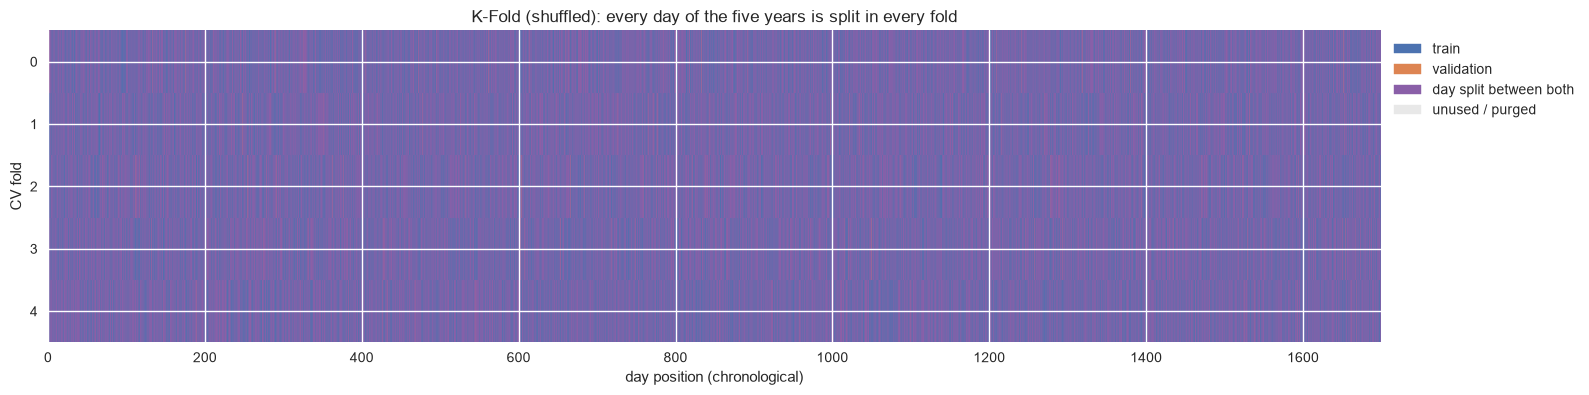

In [17]:
plot_cv_indices(kfold, X_train, groups=groups_train,
                title="K-Fold (shuffled): every day of the five years is split in every fold")

The fold-anatomy heatmap tells the same story five times over - and remember how to read it: blue means a day used purely for training, orange purely for validation, violet means *the day itself is split between the two*. Every fold's row is wall-to-wall violet. Not one of the ~1,700 days, in any fold, is cleanly on one side of the boundary: a shuffled 20% draw takes about ten of each day's fifty rows for validation and trains on the other forty. There is no arrangement of time here at all - only a uniform mist of contamination. Compare this picture against every plot that follows: the entire rest of the notebook is, visually, the process of separating this violet into clean blue and clean orange.

# Respecting the arrow of time

Everything from here on obeys one rule: **in every split, all training rows come strictly before all validation rows.** Each subsequent method keeps this rule and adds exactly one new ingredient to fix a subtler leak the previous one missed.

## Walk-forward validation (`TimeSeriesSplit`)

**New ingredient: chronology.** Walk-forward validation - scikit-learn's `TimeSeriesSplit` - is the foundational time-aware scheme. It slices the timeline into consecutive segments and rolls the forecasting origin forward: train on the first segment, validate on the second; train on the first two, validate on the third; and so on. Every fold is a miniature dress rehearsal of deployment: fit on the past, predict the immediately-following future. By default the training window **expands** - each fold trains on all history accumulated so far.

In [18]:
ts_split = TimeSeriesSplit(n_splits=CFG.n_folds)   # expanding window (default)
ts_val_rmse = cv_estimate(ts_split, X_train, y_train)

print("TimeSeriesSplit (expanding) mean validation RMSE:", ts_val_rmse)
print("True generalisation RMSE                        :", true_test_rmse)
print("Optimism (val - true)                           :", round(ts_val_rmse - true_test_rmse, 4))

TimeSeriesSplit (expanding) mean validation RMSE: 5.6934
True generalisation RMSE                        : 5.4454
Optimism (val - true)                           : 0.248


The change is night and day. The validation estimate jumps from the shuffled methods' fantasy of ≈ 3.3 up to ≈ 5.7 - within a few percent of the true 5.45, and on the **conservative** side rather than the optimistic one. Simply refusing to train on the future eliminated the bulk of a 40% error underestimate. No other single change in this notebook buys as much.

Why slightly conservative rather than exact? Two honest reasons. Early folds train on only a fraction of the history - fold 0 sees less than a fifth of the data, and its harder scores pull the average up. And on trending data every fold genuinely faces the deployment problem: predicting a level slightly above anything in its training range. That difficulty is *real* - the sealed hold-out poses it too - which is exactly why the walk-forward estimate lands close to the truth.

/Users/kbanachewicz/Documents/time-series-with-Konrad/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1262: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


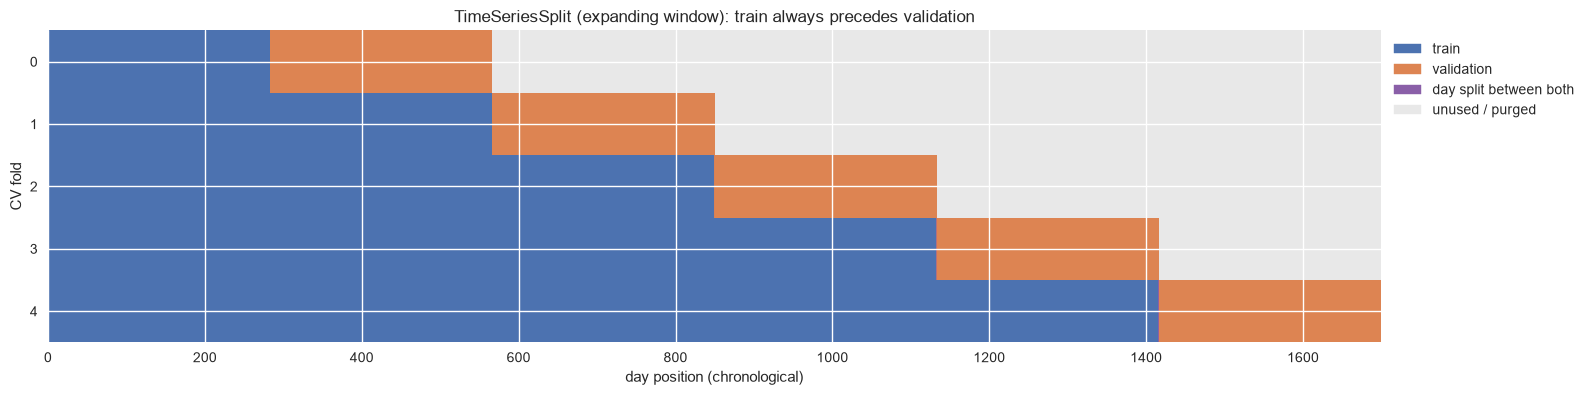

In [19]:
plot_cv_indices(ts_split, X_train, groups=groups_train,
                title="TimeSeriesSplit (expanding window): train always precedes validation")

The anatomy is now unmistakable and exactly what we want: a clean staircase. In every fold the blue training block sits entirely to the *left* of the orange validation block, the grey tail to the right is simply the not-yet-reached future that the fold does not use, and the expanding window is visible as each successive training block growing longer. Compare with the K-Fold picture above: same data, same model, and the only difference is that the violet mist has been separated into clean blue and clean orange. That difference is worth about 2.4 units of RMSE honesty.

One thing this zoomed-out view *cannot* show: at each blue/orange boundary there is a single violet column one day wide, where the row-based cut slices a day in half. It is invisible at this resolution - which is fitting, because it is also invisible to `TimeSeriesSplit` itself. We hunt it down numerically two cells below.

In [20]:
# A fixed-size ("sliding") window: keep only the most recent year of training rows.
n_items = df['item'].nunique()
SLIDING_TRAIN_SIZE = 365 * n_items          # one year of days x 50 items = rows

ts_sliding = TimeSeriesSplit(n_splits=CFG.n_folds, max_train_size=SLIDING_TRAIN_SIZE)
ts_sliding_val_rmse = cv_estimate(ts_sliding, X_train, y_train)

print("TimeSeriesSplit (sliding, 1y) mean validation RMSE:", ts_sliding_val_rmse)
print("Optimism (val - true)                             :",
      round(ts_sliding_val_rmse - true_test_rmse, 4))

TimeSeriesSplit (sliding, 1y) mean validation RMSE: 6.7044
Optimism (val - true)                             : 1.259


`TimeSeriesSplit` offers a second flavour via **`max_train_size`**: cap the training window so that, as the origin slides forward, the oldest observations drop off the back. Here the cap is one year's worth of rows (365 days × 50 items).

The estimate comes out distinctly *more pessimistic* (≈ 6.7): on this dataset, discarding history hurts, because the process is stable enough that old years still teach useful things - above all, what a full yearly seasonal cycle looks like. A one-year window means each fold has seen every calendar season exactly once; a model asked about next summer benefits from having seen four summers, not one.

The general lesson is that **the window choice is an implicit hypothesis about the data**. An expanding window bets that the data-generating process is stable and all history is relevant. A sliding window bets that the process drifts - that recent regimes matter and old ones actively mislead (the usual bet in financial markets, where relationships decay). Neither is universally right; on stable retail demand, expanding wins, and the honest way to decide for *your* data is to test both - exactly as we just did.

In [21]:
# A subtle residual leak: does row-based splitting ever cut a single day in two?
print("Days appearing in BOTH train and validation (per fold):")
for fold, (tr_idx, val_idx) in enumerate(TimeSeriesSplit(CFG.n_folds).split(X_train)):
    overlap = np.intersect1d(groups_train[tr_idx], groups_train[val_idx])
    print(f"  fold {fold}: {overlap}")

Days appearing in BOTH train and validation (per fold):
  fold 0: [283]
  fold 1: [566]
  fold 2: [850]
  fold 3: [1133]
  fold 4: [1416]


`TimeSeriesSplit` is honest about *rows* - but it knows nothing about *days*. Our data has 50 rows per day (one per item), and scikit-learn cuts the row sequence at whatever index arithmetic dictates. The check above intersects the set of days in training with the set of days in validation, per fold - and finds that **every fold slices exactly one day in half**: some of that day's items land in training while the rest land in validation.

Why care about a single day? Because of the contemporaneous correlation we saw in the raw-data plot: items in the same store on the same day share demand shocks - the same weather, the same holiday, the same footfall. Training on 30 items from a given day tells the model a great deal about the other 20 items *of that same day* sitting in validation. The model gets graded partly on questions whose context it has already seen - not forecasting, but cross-sectional interpolation.

On this dataset the contamination is one day per fold and the numeric damage is small. But scale the structure up: in the Ubiquant data there are thousands of investments per `time_id`, and a row-level cut through a timestamp leaks an entire market snapshot. The fix must guarantee that *a timestamp is never divided* - which is precisely the next rung.

## Group time-series split

**New ingredient: groups move as one.** The splitter we need combines two ideas: the chronological ordering of `TimeSeriesSplit` and the group integrity of scikit-learn's `GroupKFold` - all rows sharing a `time_id` travel together, wholly in training or wholly in validation, never straddling the boundary. Scikit-learn has no built-in that does both at once, so we write one, keeping the `.split()` interface so `cv_estimate` and `plot_cv_indices` work unchanged.

In [22]:
class GroupTimeSeriesSplit:
    """Walk-forward CV that keeps every group (here: a whole `time_id`) intact.

    Groups are ordered by first appearance; in fold k the earliest blocks of groups
    form the training set and the next `group_test_size` groups form validation.
    Training groups always precede validation groups in time.
    """
    def __init__(self, n_splits=5, max_train_size=None):
        self.n_splits = n_splits
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]          # groups in time order
        n_groups = len(ordered_groups)
        n_folds = self.n_splits + 1
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        group_test_size = n_groups // n_folds
        test_starts = range(n_groups - self.n_splits * group_test_size,
                            n_groups, group_test_size)
        for start in test_starts:
            train_groups = ordered_groups[:start]
            test_groups  = ordered_groups[start:start + group_test_size]
            train_idx = np.sort(np.concatenate([rows_of[g] for g in train_groups]))
            if self.max_train_size and len(train_idx) > self.max_train_size:
                train_idx = train_idx[-self.max_train_size:]
            test_idx = np.sort(np.concatenate([rows_of[g] for g in test_groups]))
            yield train_idx, test_idx

The class mirrors scikit-learn's splitter interface - a `.split()` method yielding `(train_indices, validation_indices)` pairs - so it drops straight into our existing engine. Walking through the mechanics:

`np.unique(groups, return_index=True)` finds each distinct day and the position where it first appears; sorting by first appearance puts the days in chronological order (for our integer `time_id` this matches numeric order, but the idiom stays correct for any sortable group label). `rows_of` is a lookup table from each day to the row positions belonging to it - built once, used every fold.

The fold geometry then copies `TimeSeriesSplit`, but **at the level of whole days**: the timeline of ~1,700 development days is divided into `n_splits + 1` consecutive blocks; fold *k* trains on all days before the *k*-th boundary and validates on the next block of days. Because train and validation are each unions of complete days, no day can ever be split - the leak we just diagnosed is structurally impossible, not merely unlikely. The optional `max_train_size` reproduces the sliding-window variant at group level.

In [23]:
group_cv = GroupTimeSeriesSplit(n_splits=CFG.n_folds)

# Confirm the boundary leak is gone.
print("Days appearing in BOTH train and validation (per fold):")
for fold, (tr_idx, val_idx) in enumerate(group_cv.split(X_train, groups=groups_train)):
    print(f"  fold {fold}: {np.intersect1d(groups_train[tr_idx], groups_train[val_idx])}")

group_val_rmse, group_scores = cv_estimate(group_cv, X_train, y_train,
                                           groups=groups_train, return_scores=True)
print("\nGroupTimeSeriesSplit mean validation RMSE:", group_val_rmse)
print("Optimism (val - true)                    :", round(group_val_rmse - true_test_rmse, 4))

Days appearing in BOTH train and validation (per fold):
  fold 0: []
  fold 1: []
  fold 2: []
  fold 3: []
  fold 4: []

GroupTimeSeriesSplit mean validation RMSE: 5.5291
Optimism (val - true)                    : 0.0837


The overlap check now prints **empty arrays** at every fold: not a single day is shared between training and validation. And the estimate lands at ≈ 5.53 against a truth of ≈ 5.45 - an optimism of under a tenth of an RMSE unit, the closest single-number claim of any method in this notebook.

We also keep the per-fold scores (`return_scores=True`) this time - they range from about 4.4 to 6.7 depending on which stretch of the calendar a fold validates on. File that spread away; it becomes the central topic two rungs up. For the mandatory-vs-optional question, the report's framing is exact: on panel data, group-aware splitting is not an upgrade, it is the *entry requirement* - `TimeSeriesSplit` on grouped rows was quietly grading itself on leaked same-day information.

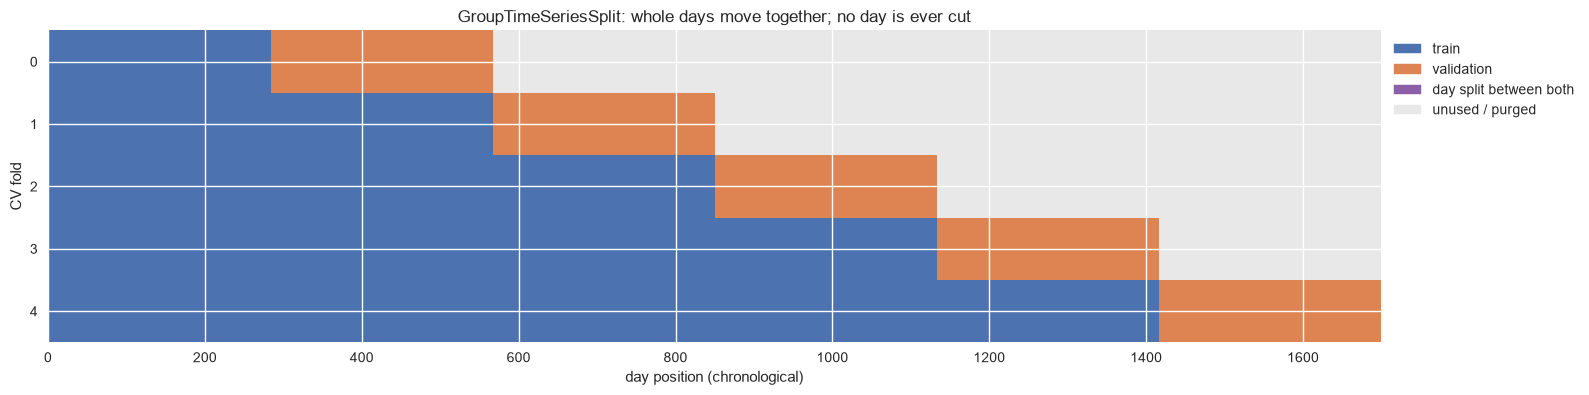

In [24]:
plot_cv_indices(group_cv, X_train, groups=groups_train,
                title="GroupTimeSeriesSplit: whole days move together; no day is ever cut")

Visually this is almost the same staircase as before - which is the point. The difference lives entirely at the five boundary columns: where the row-based splitter left a single violet (split) day at each blue/orange edge, every boundary is now a clean one-pixel transition from pure train to pure validation. Correctness in validation is often like this: the fix is microscopic in the picture and decisive in principle.

## Purged group time-series split

**New ingredient: a gap.** Chronological order and group integrity are still not enough, because our *label* has a temporal footprint. The target at day *t* is the average of sales over days *t+1 … t+7*. Now look at any train/validation boundary: the last training days' labels are computed from sales that occur *inside the validation block*. The model is trained on numbers that are, in part, summaries of the very period it is about to be graded on. Training rows whose label footprint crosses the boundary must be removed - this is **purging** (the technique popularized by Marcos López de Prado for financial labels such as the triple-barrier method, where every label depends on a future price path).

Its sibling, the **embargo**, guards the *other* direction: features with a look-back footprint (our 28-day rolling mean) computed for days just *after* a test block would summarize test-period data into any subsequent training set. In a forward-only walk that direction never occurs - training data never follows validation - so the embargo stays dormant here. It becomes essential one rung up, where combinatorial splits place training blocks after test blocks.

The implementation is `GroupTimeSeriesSplit` plus one parameter: `group_gap` days immediately before each validation block are dropped from training.

In [25]:
class PurgedGroupTimeSeriesSplit:
    """GroupTimeSeriesSplit with a `group_gap`: drop the `group_gap` groups immediately
    before each validation block, so no training label's look-ahead footprint reaches
    into the validation period (purging).
    """
    def __init__(self, n_splits=5, group_gap=0, max_train_size=None):
        self.n_splits = n_splits
        self.group_gap = group_gap
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]
        n_groups = len(ordered_groups)
        n_folds = self.n_splits + 1
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        group_test_size = n_groups // n_folds
        test_starts = range(n_groups - self.n_splits * group_test_size,
                            n_groups, group_test_size)
        for start in test_starts:
            train_end = max(0, start - self.group_gap)          # <-- the purge gap
            train_groups = ordered_groups[:train_end]
            test_groups  = ordered_groups[start:start + group_test_size]
            train_idx = np.sort(np.concatenate([rows_of[g] for g in train_groups])) \
                        if len(train_groups) else np.array([], dtype=int)
            if self.max_train_size and len(train_idx) > self.max_train_size:
                train_idx = train_idx[-self.max_train_size:]
            test_idx = np.sort(np.concatenate([rows_of[g] for g in test_groups]))
            yield train_idx, test_idx

One line changed, and it is marked in the code: `train_end = max(0, start - self.group_gap)`. Instead of training on every day up to the validation block, we stop `group_gap` days early. With `group_gap = CFG.horizon = 7`, every training row's label window - 7 days of look-ahead - closes *before* the validation block opens. The sizing rule is not arbitrary: **the gap must be at least the label's look-ahead footprint**. A shorter gap leaves residual overlap; a much longer one throws away clean data. (This is the same reasoning we already applied once, quietly, when fitting the reference model with the `label_ready` mask.)

In [26]:
purged_cv = PurgedGroupTimeSeriesSplit(n_splits=CFG.n_folds, group_gap=CFG.horizon)
purged_val_rmse, purged_scores = cv_estimate(purged_cv, X_train, y_train,
                                             groups=groups_train, return_scores=True)

print(f"PurgedGroupTimeSeriesSplit (gap={CFG.horizon}d) mean validation RMSE:", purged_val_rmse)
print("Optimism (val - true)                                       :",
      round(purged_val_rmse - true_test_rmse, 4))
print("\nPer-fold RMSE, unpurged:", [round(s, 2) for s in group_scores])
print("Per-fold RMSE, purged  :", [round(s, 2) for s in purged_scores])

PurgedGroupTimeSeriesSplit (gap=7d) mean validation RMSE: 6.2276
Optimism (val - true)                                       : 0.7822

Per-fold RMSE, unpurged: [5.79, 4.51, 4.39, 6.24, 6.71]
Per-fold RMSE, purged  : [5.78, 4.78, 4.6, 5.95, 10.03]


With the gap in place the estimate moves to the **conservative** side of the truth (≈ 6.2 vs ≈ 5.45) - and the per-fold comparison shows exactly where and why. Folds 0–3 barely move: losing 7 days of training out of hundreds costs little, and the purged handful of boundary-leaking rows (7 days × 50 items per fold, out of tens of thousands) was too small a fraction to have inflated the unpurged scores much. Fold 4 is the outlier: its score jumps hard once the week before its validation block is withheld. Its validation block is the long final stretch of the development period - the part that sits highest on the five-year trend - and a tree ensemble extrapolates a trend essentially by carrying its most recent mapping forward. That makes the freshest training week disproportionately load-bearing: withhold it, and the model's systematic under-prediction of the trending 2017 levels roughly doubles. (If you instead carve the same seven days out of the *middle* of the training set, the score barely moves - it is recency fold 4 misses, not quantity.)

Two lessons, one honest and one cautionary. The honest one: on *this* dataset, purging changes the verdict only modestly, and the report says the same - the improvement over plain group splitting is often marginal. But the contamination fraction scales with `horizon / block_length`: give labels a 30-day footprint and validation blocks a few weeks, as is routine in finance, and the leaked share of training data stops being negligible. Purging is cheap insurance whose payout grows with exactly the problems you cannot see coming.

The cautionary one: notice how much fold 4's score moved on a 7-day change in training data. A single-path estimate is hostage to *where its boundaries happen to fall* relative to the calendar. That fragility is not fixable by any amount of purging - it needs a different idea altogether, which is the final rung.

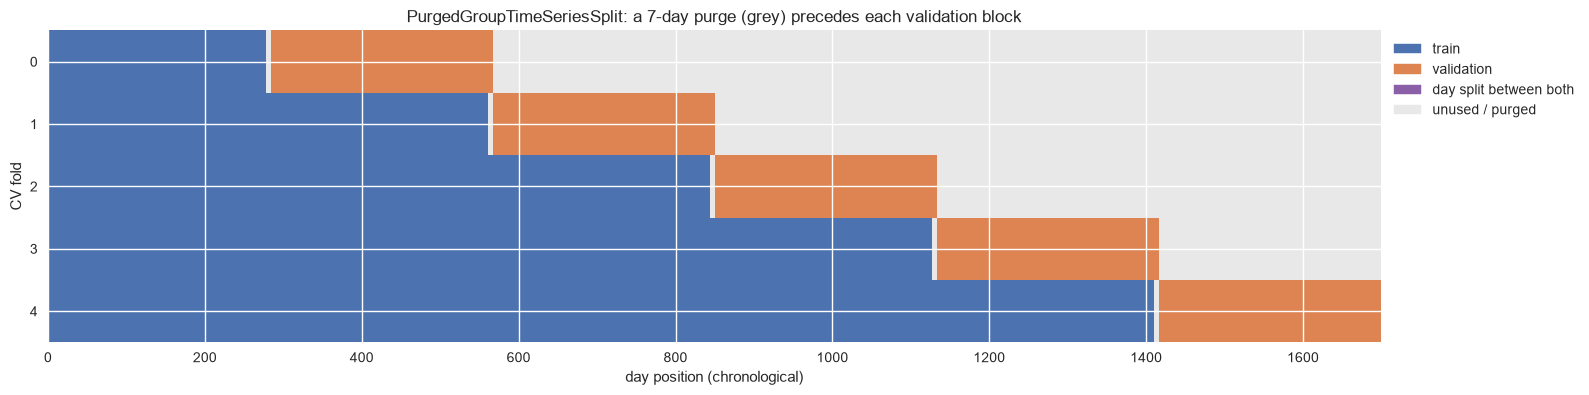

In [27]:
plot_cv_indices(purged_cv, X_train, groups=groups_train,
                title=f"PurgedGroupTimeSeriesSplit: a {CFG.horizon}-day purge (grey) precedes each validation block")

The purge appears as a thin grey seam between the end of each blue training block and the start of the orange validation block - look closely, it is only seven days wide against a 1,700-day axis. Seven days of deliberately discarded data per fold looks like waste; it is the price of a training set whose every label was knowable before the validation period began.

# Beyond a single path: Combinatorial Purged CV

Every method so far - however careful about chronology, groups, and purging - evaluates the model along **one** historical path: train on the past, test on what follows, always in the same order, with boundaries at the same calendar dates. The estimate you get is conditional on that single arrangement. We have already seen the symptom twice: fold scores ranging from ~4.4 to ~6.7 depending on the season being validated, and one fold swinging by three RMSE units when its boundary shifted a week. If your one path happens to test on benign stretches, you overestimate the model; if on brutal ones, you underestimate it. Tuning against a single path quietly overfits the *backtest itself*.

**New ingredient: many alternate histories.** Combinatorial Purged Cross-Validation (CPCV) breaks the single-path dependence. Cut the timeline into *N* equal blocks of whole days; choose every possible combination of *k* blocks as the test set, training on the rest; purge and embargo around every test block. Each combination is a small alternate history, and the collection yields not one number but a **distribution** of scores. The bookkeeping bonus: the ϕ(N, k) = (k/N)·C(N, k) distinct ways the test blocks chain together form complete backtest paths - with N = 6 and k = 2, five full alternate backtests instead of one.

The price is honesty of a different kind: many folds train on blocks that come *after* their test blocks. That is not cheating **if** the boundaries are defended on both sides - purge before each test block (the label's look-ahead), embargo after it (the features' look-back) - but it does change what is being measured, a point we return to when reading the results.

In [28]:
class CombinatorialPurgedGroupKFold:
    """Test on every combination of `n_test_splits` out of `n_splits` blocks of whole
    groups, purging `purge` groups before and embargoing `embargo` groups after each
    test block. Yields C(n_splits, n_test_splits) train/test folds.
    """
    def __init__(self, n_splits=6, n_test_splits=2, purge=0, embargo=0):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge = purge
        self.embargo = embargo

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("The 'groups' parameter is required.")
        unique, first_idx = np.unique(groups, return_index=True)
        ordered_groups = unique[np.argsort(first_idx)]
        n_groups = len(ordered_groups)
        rows_of = {g: np.where(groups == g)[0] for g in ordered_groups}

        block_size = n_groups // self.n_splits
        bounds = [(b * block_size,
                   (b + 1) * block_size if b < self.n_splits - 1 else n_groups)
                  for b in range(self.n_splits)]

        for test_blocks in combinations(range(self.n_splits), self.n_test_splits):
            test_pos, banned_pos = set(), set()
            for b in test_blocks:
                lo, hi = bounds[b]
                test_pos.update(range(lo, hi))
                banned_pos.update(range(max(0, lo - self.purge), lo))           # purge before
                banned_pos.update(range(hi, min(n_groups, hi + self.embargo)))  # embargo after
            train_pos = [p for p in range(n_groups)
                         if p not in test_pos and p not in banned_pos]
            train_idx = np.sort(np.concatenate([rows_of[ordered_groups[p]] for p in train_pos]))
            test_idx  = np.sort(np.concatenate([rows_of[ordered_groups[p]]
                                                for p in sorted(test_pos)]))
            yield train_idx, test_idx

The implementation generalizes the purged splitter from a single forward sweep to *all* combinations. It cuts the ordered days into `n_splits` contiguous blocks (`bounds` holds each block's start/end **positions** in the day sequence - positions, not day values, so the arithmetic is robust no matter what the group labels are). Then `itertools.combinations` enumerates every way to pick `n_test_splits` blocks as the test set.

The two guards now work as a pair, and asymmetrically - this is the heart of the class:

- **Purge before** each test block (`purge` days): a training day just *before* a test block has a label reaching forward into it. Sized by the label's look-ahead footprint: `horizon = 7`.
- **Embargo after** each test block (`embargo` days): a training day just *after* a test block - a situation that only exists now that training data may follow test data - has rolling features reaching *back* into it. Sized by the feature's look-back footprint: `roll_window = 28`.

Everything not in a test block and not banned is training data. Each yielded fold may therefore train on blocks both before and after its test blocks - a legal "alternate history" precisely because both boundary directions are defended.

In [29]:
# How many folds and how many distinct backtest paths does our choice yield?
N_BLOCKS, K_TEST = 6, 2
n_folds = comb(N_BLOCKS, K_TEST, exact=True)
n_paths = n_folds * K_TEST // N_BLOCKS
print(f"N={N_BLOCKS} blocks, k={K_TEST} test blocks per fold")
print(f"  number of folds : C({N_BLOCKS},{K_TEST}) = {n_folds}")
print(f"  number of paths : {n_folds} * {K_TEST} / {N_BLOCKS} = {n_paths}")

N=6 blocks, k=2 test blocks per fold
  number of folds : C(6,2) = 15
  number of paths : 15 * 2 / 6 = 5


A quick combinatorial sanity check before running anything. With *N* = 6 blocks and *k* = 2 test blocks per fold there are C(6, 2) = **15 folds** to fit - a threefold increase in compute over our 5-fold walk-forwards, and the reason CPCV is described as expensive. Each block appears in exactly `n_folds · k / N = 5` different test sets, so the fold results can be stitched into **5 complete backtest paths** - five alternate versions of history, each covering the full timeline. Compare: every previous method gave us exactly one.

In [30]:
cpcv = CombinatorialPurgedGroupKFold(n_splits=N_BLOCKS, n_test_splits=K_TEST,
                                     purge=CFG.horizon, embargo=CFG.roll_window)
_, cpcv_scores = cv_estimate(cpcv, X_train, y_train, groups=groups_train, return_scores=True)

cpcv_mean = float(np.round(np.mean(cpcv_scores), 4))
cpcv_std  = float(np.round(np.std(cpcv_scores), 4))
print("CPCV per-fold RMSEs :", [round(s, 3) for s in cpcv_scores])
print("CPCV mean RMSE      :", cpcv_mean, " | std:", cpcv_std)
print("True generalisation :", true_test_rmse)

CPCV per-fold RMSEs : [3.544, 3.965, 3.973, 4.305, 6.22, 3.742, 3.795, 4.068, 7.623, 3.833, 4.082, 8.365, 4.202, 7.656, 5.46]
CPCV mean RMSE      : 4.9889  | std: 1.6007
True generalisation : 5.4454


Running CPCV through the same engine - `purge=7` matching the label footprint, `embargo=28` matching the feature footprint - yields a *vector* of 15 scores, and the vector is the point. The scores range from roughly **3.5 to 8.4** around a mean near 5, with a standard deviation of about 1.6. The sealed-future truth of ≈ 5.45 sits comfortably inside the distribution.

Read the spread before the mean. The low scores come from folds whose test blocks sit in the *interior* of the timeline, with training data on both sides - those folds **interpolate**, and interpolating a trending series is genuinely easier than extrapolating it. The high scores come from folds whose test sets include the final, highest-level block, with no later data to lean on - the folds that most resemble actual deployment, and they populate the entire upper tail of the distribution. The mean therefore lands a shade optimistic; a practitioner who cares about deployment reads the *upper tail* - the forward-looking folds - as the stress scenario, and the standard deviation as a direct measurement of the model's **regime sensitivity**, the very quantity every single-path method silently marginalized away.

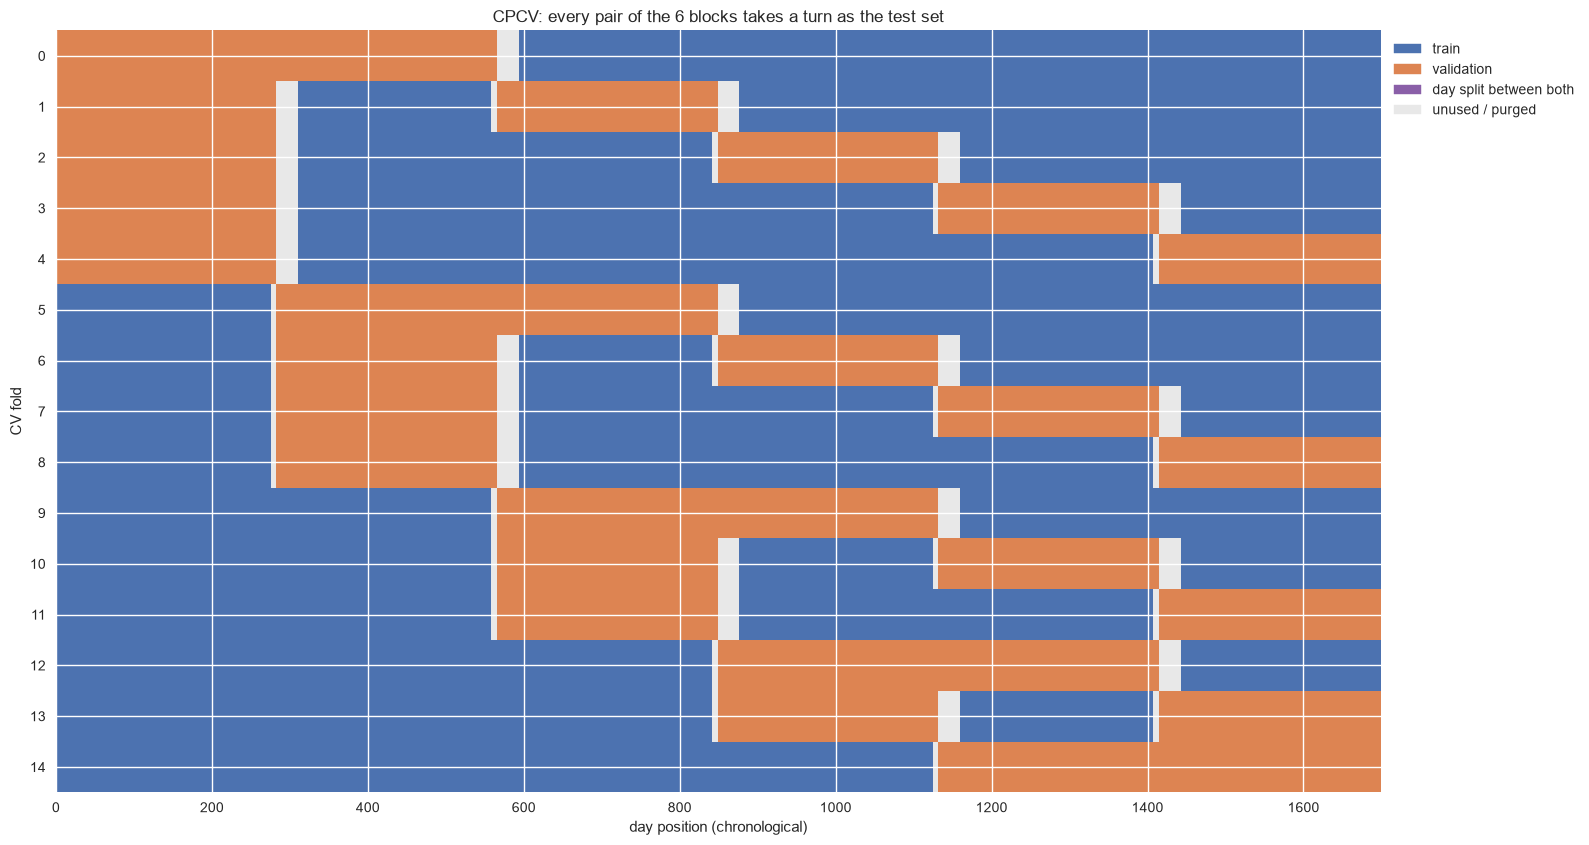

In [31]:
plot_cv_indices(cpcv, X_train, groups=groups_train,
                title="CPCV: every pair of the 6 blocks takes a turn as the test set")

The anatomy plot makes CPCV's departure from walk-forward vivid: orange test blocks now appear at *every* position along the timeline, not just at the trailing edge, and many folds train on blue blocks sitting **after** their test blocks - the legal "alternate histories". The double defense is visible too: each orange block is flanked by grey seams, the 7-day purge on its left and the wider 28-day embargo on its right, keeping label look-ahead and feature look-back from crossing either boundary.

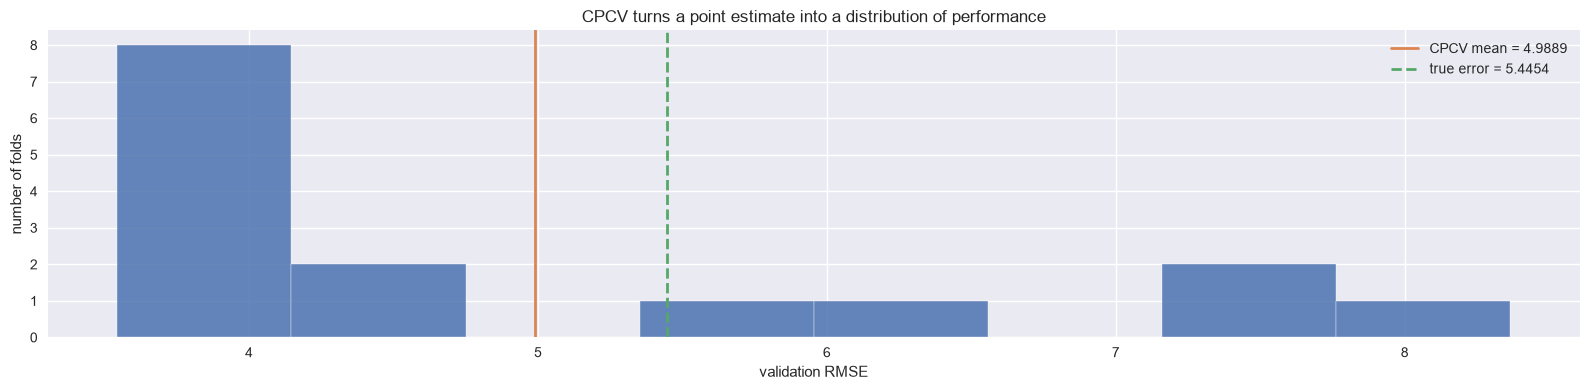

In [32]:
plt.figure(figsize=(CFG.img_dim1, 4))
plt.hist(cpcv_scores, bins=8, color="#4C72B0", edgecolor="white", alpha=0.85)
plt.axvline(cpcv_mean, color="#DD8452", linestyle="-", linewidth=2,
            label=f"CPCV mean = {cpcv_mean}")
plt.axvline(true_test_rmse, color="#55A868", linestyle="--", linewidth=2,
            label=f"true error = {true_test_rmse}")
plt.title("CPCV turns a point estimate into a distribution of performance")
plt.xlabel("validation RMSE"); plt.ylabel("number of folds")
plt.legend(); plt.tight_layout(); plt.show()

The histogram is the payoff of the whole notebook. Where every earlier method handed us a single bar - one number, take it or leave it - CPCV hands us a shape: a main mass of easy interpolating folds around 4, and a heavy right tail of hard forward-looking folds reaching past 8, with the true error (green dashed line) falling inside the distribution. This changes the *kind* of question validation can answer. Not just "what error should I expect?" but "what is the plausible range?", "how bad is the bad case?", and - for a trading strategy, where each fold's score would be a Sharpe ratio - "what is the probability this apparent performance is luck?". Validation stops being estimation and becomes risk assessment.

# Putting it together: the comparison

We have walked one real dataset up the full ladder. Now we collect every method's claim into one table, next to the sealed-future truth they were all trying to estimate.

In [33]:
results = [
    summarise("Random split",               random_val_rmse,      true_test_rmse),
    summarise("K-Fold (shuffled)",          kfold_val_rmse,       true_test_rmse),
    summarise("TimeSeriesSplit (expanding)", ts_val_rmse,         true_test_rmse),
    summarise("TimeSeriesSplit (sliding)",  ts_sliding_val_rmse,  true_test_rmse),
    summarise("GroupTimeSeriesSplit",       group_val_rmse,       true_test_rmse),
    summarise("PurgedGroupTimeSeriesSplit", purged_val_rmse,      true_test_rmse),
    summarise("CPCV (mean of 15 folds)",    cpcv_mean,            true_test_rmse),
]
results_df = pd.DataFrame(results)
results_df

,method,cv_val_rmse,true_test_rmse,optimism
0,Random split,3.2750,5.4454,-2.1704
1,K-Fold (shuffled),3.2498,5.4454,-2.1956
2,TimeSeriesSplit (expanding),5.6934,5.4454,0.2480
3,TimeSeriesSplit (sliding),6.7044,5.4454,1.2590
4,GroupTimeSeriesSplit,5.5291,5.4454,0.0837
5,PurgedGroupTimeSeriesSplit,6.2276,5.4454,0.7822
6,CPCV (mean of 15 folds),4.9889,5.4454,-0.4565


The table lays the whole argument bare. Read the `optimism` column top to bottom: the two shuffled methods post large **negative** values - they underestimated the true error by around 2.2 units, roughly 40%, by training on the future. The moment chronology is enforced, optimism collapses to a fraction of a unit. The group split turns in the single most accurate claim; purging trades a little accuracy of the point estimate for a guarantee about contamination, landing conservative; the sliding window is honest but handicapped by its short memory; and CPCV's mean sits slightly below truth for the structural reason just discussed - its fold *distribution*, not visible in a one-number column, is where its real value lives.

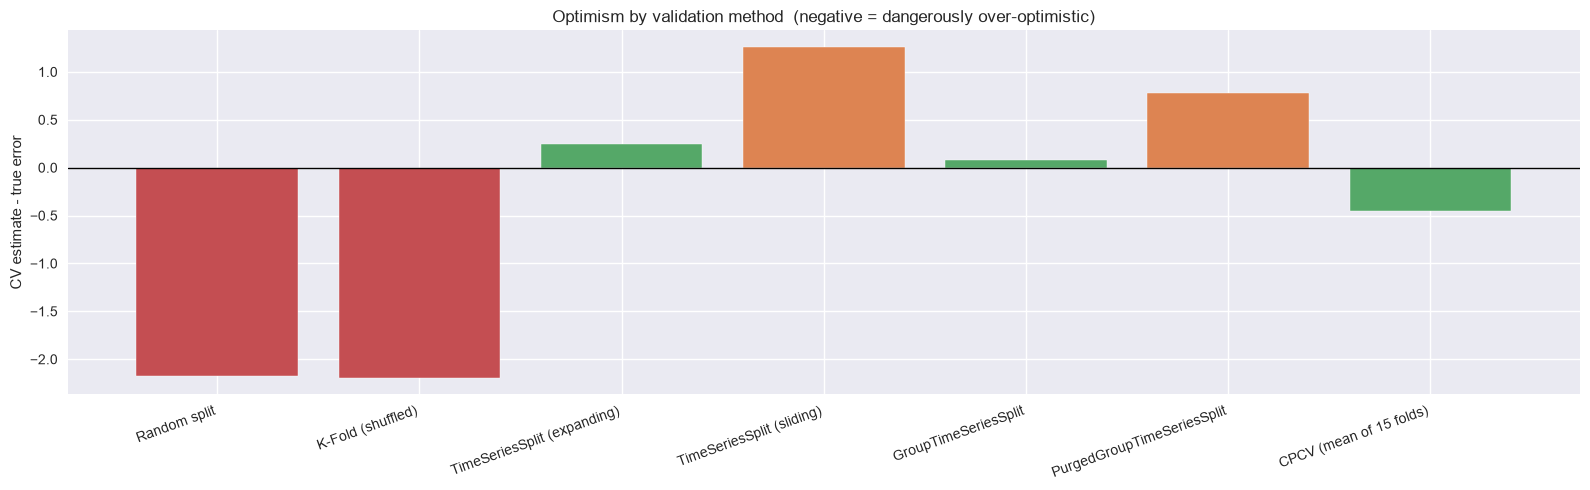

In [34]:
order  = results_df["method"].tolist()
colors = ["#C44E52" if o < -0.5 else "#55A868" if abs(o) <= 0.5 else "#DD8452"
          for o in results_df["optimism"]]
plt.figure(figsize=(CFG.img_dim1, 5))
plt.bar(order, results_df["optimism"], color=colors, edgecolor="white")
plt.axhline(0, color="black", linewidth=1)
plt.title("Optimism by validation method  (negative = dangerously over-optimistic)")
plt.ylabel("CV estimate - true error"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

The same numbers as a bar chart, colored by verdict: **red** where a method under-reports the true error by more than half an RMSE unit (the dangerous direction - you would deploy on false confidence), **green** within half a unit of honest, **orange** where the method is conservative by more than half a unit (the safe but wasteful direction). The visual summary of five years of daily data, seven methods, and one sealed future: everything left of `TimeSeriesSplit` is fantasy; everything from it rightward is a defensible, increasingly careful answer to the same question.

## Summary table of validation strategies

Pulling back from our one experiment to the general properties of each method:

| Feature | Random Split | K-Fold | TimeSeriesSplit | GroupTimeSeriesSplit | PurgedGroupTimeSeriesSplit | CPCV |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Respects temporal order | No | No | Yes | Yes | Yes | Yes (within paths) |
| Prevents shuffle leakage | No | No | Yes | Yes | Yes | Yes |
| Prevents intra-group leakage | No | No | No | Yes | Yes | Yes |
| Prevents footprint leakage (labels/features) | No | No | No | No | Yes (purge) | Yes (purge + embargo) |
| Handles panel/grouped data | No | No | No | Yes | Yes | Yes |
| Output | Point | Point | Point | Point | Point | **Distribution** |
| Robustness of estimate | Very low (overfit) | Very low (overfit) | Low (single path) | Low (single path) | Medium (single path) | High (distributional) |
| Computational cost | Low | Low | Medium | Medium | Medium | High (C(N,k) fits) |
| Observed optimism here | Extreme (−40%) | Extreme (−40%) | Small | Minimal | Small, conservative | Small (read the spread) |

## A practitioner's guide to choosing

The table is not a ranking to read bottom-up and always pick the last row; the right method is dictated by the structure of your data and the stakes of your decision:

- **Simple univariate series, simple features, next-step labels** → **`TimeSeriesSplit`** is a valid baseline. Test both the expanding and the sliding window: the choice encodes your belief about stability versus drift, and - as our sliding run showed - the data will tell you which belief it rewards.
- **Panel data - multiple entities per timestamp** (stocks per `time_id`, items per day, sensors per reading) → **group-aware splitting is the mandatory minimum**, not an optimization. A timestamp must never be divided.
- **Engineered features with look-back windows, or labels with look-ahead horizons** (rolling statistics, multi-day targets, triple-barrier labels) → add **purging** sized to the label footprint, and an **embargo** sized to the feature footprint wherever training data can follow test data. If you cannot state your label's footprint, you cannot know your leak.
- **High-stakes model or strategy selection, where the backtest itself drives the decision** → **CPCV**. Pay the C(N, k) compute; in exchange the single fragile number becomes a distribution, the worst case becomes visible, and "was it luck?" becomes an answerable question.

And one rule that survives every rung of the ladder: **keep one final chronological hold-out that no validation method, however sophisticated, is allowed to touch.** It is the only estimate that shares the one property reality insists on - the future comes strictly after everything you knew.

---

That completes the tour. We took a real retail panel, sealed away its final three months, and asked seven validation methods the same question: *how well will this model do on data it has never seen?* The shuffled methods answered with a confident fantasy, off by 40%, built entirely from leaked future information. Enforcing chronology recovered honesty at a stroke; group integrity closed the same-day leak that row-based splitting cannot see; purging closed the subtler leak carried by forward-looking labels; and the combinatorial method replaced the single fragile number with a distribution that finally showed us how much the answer depends on which future you get.

The uncomfortable truth underneath it all: a validation score is a claim about the future made from inside the past, and every shortcut in the splitting scheme is a loan taken out against deployment. The methods on the upper rungs are not more clever - they are more honest about what could not have been known, and honesty, in forecasting, is the whole game.